## Snippet 1- Prepare chapter support code
Chapter 5 begins by preparing the notebook environment before modeling theoretical distributions. This setup makes shared Think Stats helper functions available for simulation, plotting, and later distribution comparisons.

In [2]:
# Data Loading

"""
Context: prepares support code before modeling theoretical distributions.
Plain-English: loads a helper file from the Think Stats repository only when needed.
Reappears: yes in later setup cells for data files.
"""

from os.path import basename, exists  

def download(url):
    filename = basename(url)

    print(f" Downloaded {filename} from URL") 
     
    if not exists(filename):
        from urllib.request import urlretrieve  

        local, _ = urlretrieve(url, filename)  

        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")  # download support module

"""
Interpretation:
This cell defines `download` and prepares `thinkstats.py`.
If the file already exists, the notebook only shows the check message.
If the file is missing, the notebook downloads the file and prints the saved name.
A common error means the internet connection failed, or the URL is unavailable.
"""

 Downloaded thinkstats.py from URL


'\nInterpretation:\nThis cell defines `download` and prepares `thinkstats.py`.\nIf the file already exists, the notebook only shows the check message.\nIf the file is missing, the notebook downloads the file and prints the saved name.\nA common error means the internet connection failed, or the URL is unavailable.\n'

## Snippet 2- Simulate skeet shooting rounds
Chapter 5 begins modeling distributions with skeet shooting because each target is a repeated hit-or-miss trial. This snippet first simulates individual shots, then simulates many rounds of 25 targets so the chapter can compare the simulated scores with the binomial model next.

One simulated round =  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1]
PMF of hit and miss =
 0    0.101
1    0.899
Name: , dtype: float64
Mean simulation and expected mean =  22.522 22.5
PMF of simulated scores =
 17    0.001
18    0.012
19    0.019
20    0.054
21    0.142
22    0.237
23    0.256
24    0.211
25    0.068
Name: simulation results, dtype: float64


'\nInterpretation:\nflip simulates one target sequence using 1 for hit and 0 for miss\nthe first print shows one simulated 25-target round\nPMF of hit and miss checks the simulated proportions of 0 and 1\nsimulate_round adds hits across 25 targets to make one score\nresults_sim stores many simulated scores from repeated rounds\nmean comparison checks the simulation average against n*p\nthe final PMF stores probability mass for each simulated score\nthe plot shows hits on the x-axis and probability mass on the y-axis\n'

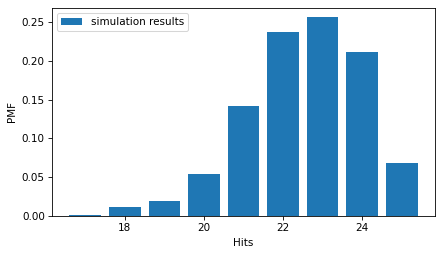

In [4]:
# Model Fitting

"""
Context: introduces skeet shooting as repeated hit-or-miss trials, later binomial modeling uses this setup
Plain-English: simulates shots, checks hit proportions, repeats rounds, then plots score probabilities
Real-world: used for repeated yes-or-no outcomes like hit or miss, pass or fail, success or failure
Reappears: yes in binomial distribution and model comparison
"""


import numpy as np
from empiricaldist import Pmf
from thinkstats import decorate

def flip(n, p):
    choices = [1, 0]  
    # possible outcomes: 1 means hit, 0 means miss

    probs = [p, 1 - p]  
    # probability of hit and miss

    return np.random.choice(choices, n, p=probs)  
    # choose n outcomes using given probabilities


# Seed the random number generator so we get the same results every time
np.random.seed(1)

round_result = flip(25, 0.9)  
# simulate 25 targets with 90% hit chance

print(
    "One simulated round = ", round_result
     )


seq = flip(1000, 0.9)  
# simulate many single shots

pmf = Pmf.from_seq(seq)  
# make PMF from hit and miss outcomes

print(
    "PMF of hit and miss =\n", pmf
     )


def simulate_round(n, p):
    seq = flip(n, p)  
    # simulate one full round

    return seq.sum()  
    # count total hits

n = 25  
# targets per round

p = 0.9  
# probability of hitting each target

results_sim = [simulate_round(n, p) for i in range(1000)]  
# simulate 1000 rounds

mean_sim = np.mean(results_sim)  
# compute average simulated score

expected_mean = n * p  
# compute expected score from n times p

print(
    "Mean simulation and expected mean = ", mean_sim, expected_mean
     )



pmf_sim = Pmf.from_seq(results_sim, name="simulation results")  
# make PMF of simulated scores

print(
    "PMF of simulated scores =\n", pmf_sim
     )

pmf_sim.bar()  
# plot simulated score distribution

decorate(xlabel="Hits", ylabel="PMF")  
# label axes


"""
Interpretation:
flip simulates one target sequence using 1 for hit and 0 for miss
the first print shows one simulated 25-target round
PMF of hit and miss checks the simulated proportions of 0 and 1
simulate_round adds hits across 25 targets to make one score
results_sim stores many simulated scores from repeated rounds
mean comparison checks the simulation average against n*p
the final PMF stores probability mass for each simulated score
the plot shows hits on the x-axis and probability mass on the y-axis
"""

## Snippet 3- Compare simulation with the binomial model
After simulating skeet shooting rounds, Chapter 5 introduces the binomial formula for repeated hit-or-miss trials. This snippet builds the theoretical PMF for possible scores, then compares it with the simulated PMF from the previous snippet.

Binomial model PMF =
 16    0.000379
17    0.001804
18    0.007215
19    0.023924
20    0.064594
21    0.138415
22    0.226497
23    0.265888
24    0.199416
25    0.071790
Name: binomial model, dtype: float64


'\nInterpretation:\nbinomial_pmf computes the theoretical probability for each score\nks stores the score range used for this comparison\npmf_binom stores the binomial model as a PMF\nthe printed PMF shows model probability for each possible hit count\nthe plot compares simulated results with the binomial model\nthe x-axis shows hits and the y-axis shows probability mass\nclose bars mean the simulation agrees with the model\n'

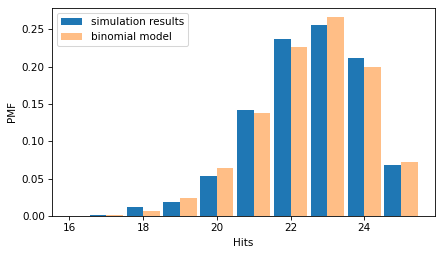

In [5]:
# Model Fitting

"""
Context: connects the skeet simulation to the binomial model, using the same n and p
Plain-English: computes binomial probabilities, builds a model PMF, then compares it with simulation
Real-world: used when repeated yes-or-no trials share the same success probability
Reappears: yes in later model comparison and theoretical distribution sections
"""

import numpy as np
from scipy.special import comb
from empiricaldist import Pmf
from thinkstats import two_bar_plots, decorate


def binomial_pmf(k, n, p):
    return comb(n, k) * (p**k) * ((1 - p) ** (n - k))  
    # compute binomial probability for k hits


ks = np.arange(16, n + 1)  
# possible hit counts shown in the comparison

ps = binomial_pmf(ks, n, p)  
# compute model probabilities for each hit count

pmf_binom = Pmf(ps, ks, name="binomial model")  
# store binomial probabilities as a PMF

print(
    "Binomial model PMF =\n", pmf_binom
     )


two_bar_plots(pmf_sim, pmf_binom)  
# compare simulated PMF with binomial model PMF

decorate(xlabel="Hits", ylabel="PMF")  
# label axes


"""
Interpretation:
binomial_pmf computes the theoretical probability for each score
ks stores the score range used for this comparison
pmf_binom stores the binomial model as a PMF
the printed PMF shows model probability for each possible hit count
the plot compares simulated results with the binomial model
the x-axis shows hits and the y-axis shows probability mass
close bars mean the simulation agrees with the model
"""

## Snippet 4- Compare Olympic skeet scores with the binomial model
After comparing simulation with the binomial model, it brings in real Olympic skeet results. This snippet estimates the hit probability from actual scores, builds a binomial model from that estimate, and compares the model with the observed score distribution.

 Downloaded Shooting_at_the_2020_Summer_Olympics_Mens_skeet from URL


First five rows of selected table =
    Rank              Athlete        Country   1   2   3   4   5 Total[3]  \
0     1        Éric Delaunay         France  25  25  25  24  25      124   
1     2    Tammaro Cassandro          Italy  24  25  25  25  25      124   
2     3      Eetu Kallioinen        Finland  25  25  24  25  24      123   
3     4      Vincent Hancock  United States  25  25  25  25  22      122   
4     5  Abdullah Al-Rashidi         Kuwait  25  25  24  25  23      122   

  Shoot-off  Notes  
0        +6  Q, OR  
1        +5  Q, OR  
2       NaN      Q  
3        +8      Q  
4        +7      Q  
Targets per round, total shots, total hits =  25 3750 3575
Estimated hit probability =  0.9533333333333334
Binomial model PMF =
 16    9.982528e-07
17    1.079623e-05
18    9.802291e-05
19    7.377514e-04
20    4.521362e-03
21    2.199166e-02
22    8.168331e-02
23    2.176530e-01
24    3.705284e-01
25    3.027746e-01
Name: binomial model, dtype: float64
Actual results PMF =
 19

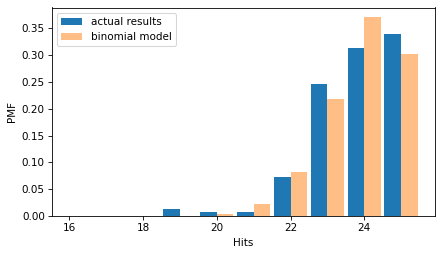

In [18]:
# Model Fitting

"""
Context: uses real Olympic skeet scores after simulation and binomial modeling
Plain-English: loads real scores, estimates hit probability, builds a binomial PMF, then compares it with actual results
Real-world: used to check whether a simple model fits real competition data
Reappears: yes in model checking and distribution comparison
"""

import pandas as pd
from empiricaldist import Pmf
from thinkstats import two_bar_plots, decorate


filename = "Shooting_at_the_2020_Summer_Olympics_Mens_skeet"  
# store local filename for Olympic skeet results

from os.path import basename, exists  

def download(url):
    filename = basename(url)

    print(f" Downloaded {filename} from URL") 
     
    if not exists(filename):
        from urllib.request import urlretrieve  

        local, _ = urlretrieve(url, filename)  

        print("Downloaded " + local)
        
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/" + filename)  
# download real Olympic skeet data


# Setup for running pd.read_html(filename)
import sys  # use notebook Python
!{sys.executable} -m pip install lxml
# install lxml for pd.read_html


tables = pd.read_html(filename)  
# read HTML tables from the saved file

table = tables[6]  
# select the table with shooting results

print(
    "First five rows of selected table =\n", table.head()
     )  
# display first rows of the selected table


columns = ["1", "2", "3", "4", "5"]  
# select five round-score columns

results = table[columns].values.flatten()  
# flatten round scores into one sequence

total_shots = 25 * len(results)  
# compute total targets across all rounds

total_hits = results.sum()  
# compute total hits across all rounds

print(
    "Targets per round, total shots, total hits = ", n, total_shots, total_hits
     )


p = total_hits / total_shots  
# estimate hit probability from actual results

print(
    "Estimated hit probability = ", p
     )


ps = binomial_pmf(ks, n, p)  
# compute binomial probabilities using estimated p

pmf_binom = Pmf(ps, ks, name="binomial model")  
# store model probabilities as a PMF

pmf_results = Pmf.from_seq(results, name="actual results")  
# store actual round scores as a PMF

print(
    "Binomial model PMF =\n", pmf_binom
     )

print(
    "Actual results PMF =\n", pmf_results
     )


two_bar_plots(pmf_results, pmf_binom)  
# compare actual scores with binomial model

decorate(xlabel="Hits", ylabel="PMF")  
# label axes


"""
Interpretation:
the table contains real Olympic skeet results
results stores all round scores from the selected score columns
p estimates the hit probability from the data itself
pmf_binom stores the binomial model based on the estimated probability
pmf_results stores the observed score distribution
the plot compares real scores with the fitted binomial model
the x-axis shows hits and the y-axis shows probability mass
similar bars suggest the simple binomial model is a reasonable fit
"""

print()


## Snippet 5- Simulate hockey goals per game
After the binomial example, Chapter 5 moves to hockey goals to introduce the Poisson distribution. This snippet treats each second of a 60-minute game as a small chance for a goal, then simulates many games so the chapter can compare the average with the Poisson model next.

In [20]:
# Distributions

"""
Context: introduces hockey scoring as many small-probability trials, later Poisson modeling uses this setup
Plain-English: sets the per-second goal probability, simulates many games, then checks the average goals
Real-world: used for counts of events over time, like goals, calls, arrivals, or defects
Reappears: yes in Poisson distribution and event-count modeling
"""

import numpy as np


n = 3600  
# seconds in a 60-minute hockey game

m = 6  
# expected goals per game

p = m / 3600  
# probability of a goal in one second

print(
    "Goal probability per second = ", p
     )


def simulate_goals(n, p):
    return flip(n, p).sum()  
    # simulate n seconds and count total goals

goals = [simulate_goals(n, p) for i in range(1001)]  
# simulate many hockey games

mean_goals = np.mean(goals)  
# compute average goals per simulated game

print(
    "Mean goals from simulation = ", mean_goals
     )


"""
Interpretation:
n represents the number of seconds in one hockey game
m represents the expected number of goals in one game
p converts the game-level average into a per-second scoring chance
simulate_goals uses flip from the earlier binomial setup
goals stores total goals from many simulated games
the mean checks whether the simulation stays close to the assumed average
this prepares the chapter to replace the binomial simulation with a Poisson model
"""

print()

Goal probability per second =  0.0016666666666666668
Mean goals from simulation =  5.92007992007992



## Snippet 6- Compare hockey simulation with the Poisson model
After simulating hockey goals as many small-probability trials, Chapter 5 introduces the Poisson distribution as a simpler model for event counts. This snippet builds the Poisson PMF for goals per game, checks its mean, and compares it with the simulated goal distribution.

Poisson model mean =  5.999925498375129
Poisson model PMF =
 0     0.002479
1     0.014873
2     0.044618
3     0.089236
4     0.133853
5     0.160624
6     0.160624
7     0.137678
8     0.103258
9     0.068839
10    0.041303
11    0.022529
12    0.011265
13    0.005199
14    0.002228
15    0.000891
16    0.000334
17    0.000118
18    0.000039
19    0.000012
Name: Poisson model, dtype: float64
Simulation PMF =
 0     0.001998
1     0.014985
2     0.045954
3     0.095904
4     0.142857
5     0.168831
6     0.156843
7     0.129870
8     0.088911
9     0.065934
10    0.050949
11    0.012987
12    0.014985
13    0.004995
14    0.001998
15    0.001998
Name: simulation, dtype: float64



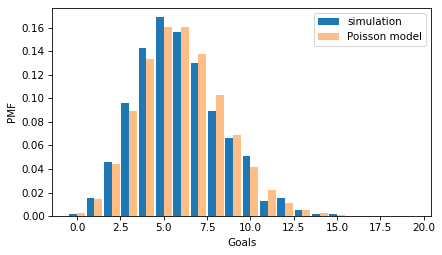

In [ ]:
# Distributions

"""
Context: introduces the Poisson model after simulating hockey goals as many small trials
Plain-English: computes Poisson probabilities, builds a PMF, checks its mean, then compares it with simulation
Real-world: used for counts of events over time, like goals, calls, arrivals, or defects
Reappears: yes in event-count modeling and distribution comparison
"""

import numpy as np
from scipy.special import factorial
from empiricaldist import Pmf
from thinkstats import two_bar_plots, decorate


def poisson_pmf(k, lam): 
    # k is the event count, lam is the average event rate
    
    return (lam**k) * np.exp(-lam) / factorial(k)  
    # compute Poisson probability for k events


lam = 6  
# average number of goals per game

ks = np.arange(20)  
# possible goal counts: 0, 1, 2, up to 19

ps = poisson_pmf(ks, lam)  
# compute model probabilities for each goal count

pmf_poisson = Pmf(ps, ks, name="Poisson model")  
# store Poisson probabilities as a PMF
# pair each goal count in ks with its probability in ps

pmf_poisson.normalize()  
# make probabilities add to 1

mean_poisson = pmf_poisson.mean()  
# compute mean of the Poisson model

print(
    "Poisson model mean = ", mean_poisson
     )


pmf_sim = Pmf.from_seq(goals, name="simulation")  
# build PMF from simulated hockey goals

print(
    "Poisson model PMF =\n", pmf_poisson
     )

print(
    "Simulation PMF =\n", pmf_sim
     )


two_bar_plots(pmf_sim, pmf_poisson)  
# compare simulated goals with Poisson model

decorate(xlabel="Goals", ylabel="PMF")  
# label axes


"""
Interpretation:
SciPy provides the factorial function, which computes the product of the integers from 1 to k
poisson_pmf computes the theoretical probability for each goal count
lam stores the average number of goals per game
ks gives the range of goal counts shown in the model
pmf_poisson stores the Poisson model as a PMF
normalizing adjusts the small missing tail beyond the selected range
mean_poisson checks the model average
pmf_sim stores the simulated goal-count distribution
the plot shows goals on the x-axis and probability mass on the y-axis
similar bars mean the Poisson model matches the simulation well
"""

print()

## Snippet 7- Compare real NHL goals with the Poisson model
After comparing hockey simulation with the Poisson model, Chapter 5 checks the same idea with real NHL scoring data. This snippet loads goal times from actual games, counts goals per game, estimates the average scoring rate, and compares the observed goal distribution with a Poisson model.

 Downloaded nhl_2023_2024.hdf from URL


Number of games and first key =  1312 /202310100PIT
Goal times for first game =
 0     424
1    1916
2    2137
3    3005
4    3329
5    3513
dtype: int64
Seconds remaining after goal time =  87
Average goals per game =  6.0182926829268295
Poisson model PMF =
 0     0.002434
1     0.014647
2     0.044076
3     0.088421
4     0.133036
5     0.160130
6     0.160619
7     0.138093
8     0.103885
9     0.069468
10    0.041808
11    0.022874
12    0.011472
13    0.005311
14    0.002283
15    0.000916
16    0.000345
17    0.000122
18    0.000041
19    0.000013
Name: Poisson model, dtype: float64
Real goals PMF =
 0     0.002287
1     0.009909
2     0.045732
3     0.070884
4     0.146341
5     0.151677
6     0.185976
7     0.137957
8     0.100610
9     0.072409
10    0.035061
11    0.028963
12    0.008384
13    0.003049
17    0.000762
Name: goals scored, dtype: float64



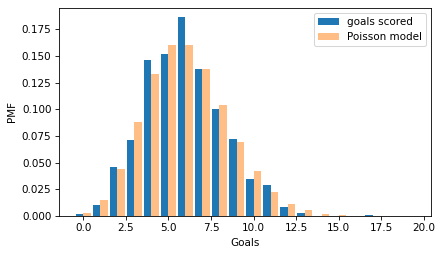

In [26]:
# Model Fitting

"""
Context: uses real NHL goal data after introducing the Poisson model with simulation
Plain-English: loads goal times, counts goals per game, estimates the average rate, then compares real goals with a Poisson PMF
Real-world: used to check whether event counts in real games follow a simple count model
Reappears: yes in model checking and distribution comparison
"""

import numpy as np
import pandas as pd
from empiricaldist import Pmf
from thinkstats import two_bar_plots, decorate

from os.path import basename, exists  

def download(url):
    filename = basename(url)

    print(f" Downloaded {filename} from URL") 
     
    if not exists(filename):
        from urllib.request import urlretrieve  

        local, _ = urlretrieve(url, filename)  

        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/nhl_2023_2024.hdf")  
# download real NHL goal-time data


filename = "nhl_2023_2024.hdf"  
# store local HDF filename


"""Setup for running pd.HDFStore() and pd.read_hdf() which are PyTables package"""

import sys  # use the same Python running this notebook
!{sys.executable} -m pip install tables
# install PyTables for reading .hdf files with pandas


with pd.HDFStore(filename, "r") as store:
    keys = store.keys()  
    # keys are table names, one key for each game

print(
    "Number of games and first key = ", len(keys), keys[0]
     )

times = pd.read_hdf(filename, key=keys[0])  
# read goal times for the first game

print(
    "Goal times for first game =\n", times
     )

time_remaining = 3600 - times[5]  
# convert one goal time to seconds remaining in regulation

print(
    "Seconds remaining after goal time = ", time_remaining
     )

goals = []  
# empty list for goals per game


for key in keys:
    times = pd.read_hdf(filename, key=key)  
    # read goal times for one game

    n = len(times)  
    # count goals in that game

    goals.append(n)  
    # save goal count

lam = np.mean(goals)  
# lam is the average number of goals per game

print(
    "Average goals per game = ", lam
     )

ps = poisson_pmf(ks, lam)  
# ps stores Poisson probabilities for each goal count in ks

pmf_poisson = Pmf(ps, ks, name="Poisson model")  
# pair each goal count in ks with its model probability

pmf_goals = Pmf.from_seq(goals, name="goals scored")  
# build PMF from real game goal counts

print(
    "Poisson model PMF =\n", pmf_poisson
     )

print(
    "Real goals PMF =\n", pmf_goals
     )

two_bar_plots(pmf_goals, pmf_poisson)  
# compare real goal counts with Poisson model

decorate(xlabel="Goals", ylabel="PMF")  
# label axes


"""
Interpretation:
keys identifies the stored game tables inside the HDF file
times stores goal times for one selected game
goals stores one total goal count for each game
lam estimates the average scoring rate from real NHL games
ps stores the model probability for each count in ks
pmf_poisson stores the fitted Poisson model
pmf_goals stores the observed distribution of goals per game
the plot shows goals on the x-axis and probability mass on the y-axis
similar bars suggest the Poisson model fits the real scoring counts well
"""

print()

## Snippet 8- Simulate time until the first hockey goal
After modeling the number of hockey goals with the Poisson distribution, it turns to the waiting time until the first goal. This snippet simulates first-goal times, estimates the scoring rate from the simulated mean, and compares the simulation with an exponential CDF.

Goal probability per second =  0.0016666666666666668
Mean first-goal time =  597.7902097902098
Estimated rate lam =  0.0016728276636563566
Exponential model CDF =
 0.0       0.000000
18.0      0.029662
36.0      0.058444
54.0      0.086373
72.0      0.113473
            ...   
3528.0    0.997265
3546.0    0.997346
3564.0    0.997425
3582.0    0.997502
3600.0    0.997576
Name: exponential model, Length: 201, dtype: float64
Simulation CDF =
 0       0.007992
1       0.008991
2       0.011988
3       0.013986
4       0.014985
          ...   
2980    0.996004
2988    0.997003
3065    0.998002
3112    0.999001
3146    1.000000
Name: simulation, Length: 711, dtype: float64



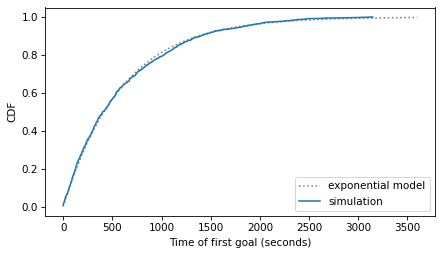

In [ ]:
# Distributions

"""
Context: introduces waiting time after Poisson goal counts, later real data checks use this model
Plain-English: simulates first-goal times, estimates the rate, builds an exponential CDF, then compares it with simulation
Real-world: used for waiting times like first goal, first call, first arrival, or first failure
Reappears: yes in exponential modeling and real-data comparison
"""

import numpy as np
from empiricaldist import Cdf
from thinkstats import decorate


n = 3600  # seconds in one 60-minute hockey game

m = 6  # expected goals per game

p = m / 3600  
# probability of a goal in one second

print(
    "Goal probability per second = ", p
     )


def simulate_first_goal(n, p):
    return flip(n, p).argmax()  
    # find index of first goal, where 1 means goal

np.random.seed(3)  
# fix randomness for repeatable simulation

first_goal_times = [simulate_first_goal(n, p) for i in range(1001)]  
# simulate first-goal time for many games

mean = np.mean(first_goal_times)  
# average time until first goal

print(
    "Mean first-goal time = ", mean
     )


def exponential_cdf(x, lam):
    return 1 - np.exp(-lam * x)  
    # x is time, lam is event rate per unit time

lam = 1 / mean  
# lam is the estimated goal rate per second

print(
    "Estimated rate lam = ", lam
     )

ts = np.linspace(0, 3600, 201)  
# time values from 0 to 3600 seconds

ps = exponential_cdf(ts, lam)  
# cumulative probabilities for each time in ts

cdf_expo = Cdf(ps, ts, name="exponential model")  
# pair each time with its model cumulative probability

cdf_sim = Cdf.from_seq(first_goal_times, name="simulation")  
# build CDF from simulated first-goal times

print(
    "Exponential model CDF =\n", cdf_expo
     )

print(
    "Simulation CDF =\n", cdf_sim
     )

cdf_expo.plot(ls=":", color="gray")  
# plot exponential model as dotted gray line

cdf_sim.plot()  
# plot simulated first-goal CDF

decorate(xlabel="Time of first goal (seconds)", ylabel="CDF")  
# label axes


"""
Interpretation:
n stores the number of seconds in one game
m stores the expected goals per game
p converts the game average into a per-second scoring chance
simulate_first_goal returns the first index where a goal appears
first_goal_times stores one first-goal time for each simulated game
mean summarizes the average waiting time until the first goal
lam estimates the scoring rate from the simulated waiting time
ts stores time values used to draw the model CDF
ps stores cumulative probabilities for each time in ts
cdf_expo stores the exponential model
cdf_sim stores the simulated first-goal distribution
the plot shows time on the x-axis and cumulative probability on the y-axis
similar curves mean the exponential model matches the simulation well
"""

print()

## Snippet 9- Compare real first-goal times with the exponential model
After simulating time until the first hockey goal, Chapter 5 checks the same exponential model with real NHL data. This snippet finds the first goal time in each game, estimates the scoring rate while ignoring games with no goals, and compares the observed CDF with the exponential model.

Estimated rate lam =  0.0015121567467720825
Tail of real first-goal CDF =
 3286.0    0.996951
3581.0    0.997713
NaN       1.000000
Name: data, dtype: float64



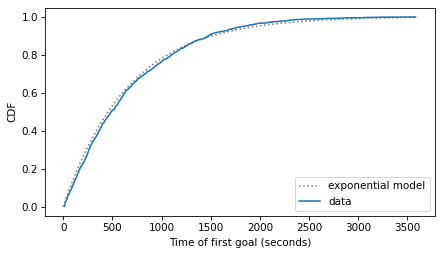

In [28]:
# Model Fitting

"""
Context: uses real NHL first-goal times after the simulated exponential model
Plain-English: loads game goal times, extracts first goals, estimates the rate, then compares real data with an exponential CDF
Real-world: used for waiting-time data where some observations can be missing
Reappears: yes in exponential modeling and model checking
"""

import numpy as np
import pandas as pd
from empiricaldist import Cdf
from thinkstats import decorate


filename = "nhl_2023_2024.hdf"  
# local HDF file with NHL goal times

"""Setup for running pd.HDFStore() and pd.read_hdf() which are PyTables package"""

import sys  # use the same Python running this notebook
!{sys.executable} -m pip install tables
# install PyTables for reading .hdf files with pandas

with pd.HDFStore(filename, "r") as store:
    keys = store.keys()  
    # keys are game IDs stored in the HDF file

firsts = []  
# empty list for first-goal times


for key in keys:
    times = pd.read_hdf(filename, key=key)  
    # read goal times for one game

    if len(times) > 0:
        firsts.append(times[0])  
        # save first goal time if the game has goals

    else:
        firsts.append(np.nan)  
        # save missing value if the game has no goals

lam = 1 / np.nanmean(firsts)  
# lam is the scoring rate, estimated from non-missing first-goal times

print(
    "Estimated rate lam = ", lam
     )

ps = exponential_cdf(ts, lam)  
# ps stores cumulative probabilities for each time in ts

cdf_expo = Cdf(ps, ts, name="exponential model")  
# pair each time in ts with its model cumulative probability

cdf_firsts = Cdf.from_seq(firsts, name="data", dropna=False)  
# build CDF from real first-goal times, keeping missing values

print(
    "Tail of real first-goal CDF =\n", cdf_firsts.tail()
     )

cdf_expo.plot(ls=":", color="gray")  
# plot exponential model as dotted gray line

cdf_firsts.plot()  
# plot real first-goal CDF

decorate(xlabel="Time of first goal (seconds)", ylabel="CDF")  
# label axes


"""
Interpretation:
keys identifies the saved game tables in the HDF file
firsts stores the first goal time for each game
np.nan marks games where no goal was scored
lam estimates the scoring rate from games with observed first goals
ps stores model cumulative probabilities for each time in ts
cdf_expo stores the exponential model
cdf_firsts stores the observed first-goal distribution
tail shows the largest time values and any missing values kept in the CDF
the plot shows time on the x-axis and cumulative probability on the y-axis
similar curves suggest the exponential model fits real first-goal times well
"""

print()

## Snippet 10- Compare additive growth with the normal model
After modeling event counts and waiting times, Chapter 5 turns to the normal distribution. This snippet simulates total weight gain as many small independent gains, then compares the simulated CDF with a normal model based on the simulated mean and standard deviation.

Mean and standard deviation =  199.37062937062936 8.388630840376777



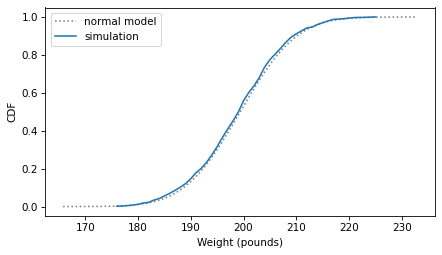

In [29]:
# Distributions

"""
Context: introduces the normal model using additive growth from many small independent gains
Plain-English: simulates many total gains, estimates mean and standard deviation, then compares the simulation with a normal CDF
Real-world: used for totals made from many small effects, like weight change, measurement error, or summed variation
Reappears: yes in normal modeling and model comparison
"""

import numpy as np
from scipy.stats import norm
from empiricaldist import Cdf
from thinkstats import decorate


def simulate_growth(n):
    choices = [1, 2, 3]  
    # possible daily gains

    gains = np.random.choice(choices, n)  
    # choose n daily gains at random

    return gains.sum()  
    # add daily gains to get total growth


sim_weights = [simulate_growth(100) for i in range(1001)]  
# simulate 1001 total weight gains over 100 days

m, s = np.mean(sim_weights), np.std(sim_weights)  
# m is mean total gain, s is standard deviation

print(
    "Mean and standard deviation = ", m, s
     )


def make_normal_model(data):
    m, s = np.mean(data), np.std(data)  
    # estimate mean and standard deviation from data

    low, high = m - 4 * s, m + 4 * s  
    # set model range around the mean

    qs = np.linspace(low, high, 201)  
    # qs are weight values used to draw the model

    ps = norm.cdf(qs, m, s)  
    # ps are cumulative probabilities for each value in qs

    return Cdf(ps, qs, name="normal model")  
    # return model CDF


cdf_model = make_normal_model(sim_weights)  
# build normal CDF from simulated weights

cdf_sim_weights = Cdf.from_seq(sim_weights, name="simulation")  
# build empirical CDF from simulated weights


def two_cdf_plots(cdf_model, cdf_data, xlabel="", **options):
    cdf_model.plot(ls=":", color="gray")  
    # plot model CDF as dotted gray line

    cdf_data.plot(**options)  
    # plot data CDF

    decorate(xlabel=xlabel, ylabel="CDF")  
    # label axes


two_cdf_plots(cdf_model, cdf_sim_weights, xlabel="Weight (pounds)")  
# compare simulated additive growth with normal model


"""
Interpretation:
simulate_growth adds many small random gains into one total
sim_weights stores many totals from repeated simulations
m stores the average simulated total
s stores how spread out the simulated totals are
make_normal_model builds a normal CDF using the data mean and standard deviation
qs stores weight values for drawing the model curve
ps stores cumulative probabilities for each value in qs
cdf_model stores the normal model
cdf_sim_weights stores the simulated growth distribution
the plot shows weight on the x-axis and cumulative probability on the y-axis
similar curves suggest the normal model fits additive growth well
"""

print()

## Snippet 11- Compare birth weights with the normal model
After showing that additive growth can look normal, Chapter 5 checks the normal model with real birth-weight data. This snippet loads NSFG pregnancy data, estimates the mean and standard deviation, trims extreme values, and compares the observed birth weights with a fitted normal CDF.

 Downloaded nsfg.py from URL
 Downloaded 2002FemPreg.dct from URL
 Downloaded 2002FemPreg.dat.gz from URL


c:\Users\DCL\Desktop\saadman vai\thinkstat\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


Mean and standard deviation before trimming =  7.265628457623368 1.40821553384062
Mean and standard deviation after trimming =  7.280883100022579 1.2430657948614345



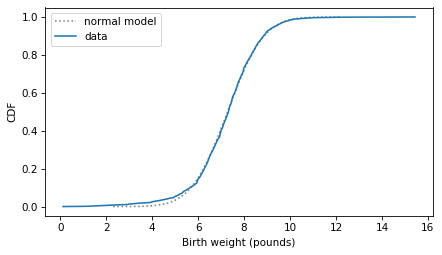

In [ ]:
# Model Fitting

"""
Context: uses real birth-weight data after introducing the normal model with simulation
Plain-English: loads birth weights, trims extreme values, builds a normal CDF, then compares it with the data
Real-world: used to check whether real measurements are close to a normal distribution
Reappears: yes in normal modeling and model checking
"""

import numpy as np
from scipy.stats import trimboth
from empiricaldist import Cdf

from os.path import basename, exists  

def download(url):
    filename = basename(url)

    print(f" Downloaded {filename} from URL") 
     
    if not exists(filename):
        from urllib.request import urlretrieve  

        local, _ = urlretrieve(url, filename)  

        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")  
# download NSFG helper module

download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")  
# download pregnancy data dictionary

download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")  
# download pregnancy data file

try:
    import statadict  
except ImportError:
    %pip install statadict  


import nsfg  
# import NSFG helper module

preg = nsfg.read_fem_preg()  
# read and clean pregnancy data

birth_weights = preg["totalwgt_lb"].dropna()  
# select birth weights and remove missing values

m, s = np.mean(birth_weights), np.std(birth_weights)  
# m is mean birth weight, s is standard deviation

print(
    "Mean and standard deviation before trimming = ", m, s
     )

trimmed = trimboth(birth_weights, 0.01)  
# remove lowest 1% and highest 1% of birth weights

m, s = np.mean(trimmed), np.std(trimmed)  
# recompute mean and standard deviation after trimming

print(
    "Mean and standard deviation after trimming = ", m, s
     )

cdf_model = make_normal_model(trimmed)  
# build normal model from trimmed birth weights

cdf_birth_weight = Cdf.from_seq(birth_weights, name="data")  
# build empirical CDF from all non-missing birth weights

two_cdf_plots(cdf_model, cdf_birth_weight, xlabel="Birth weight (pounds)")  
# compare real birth weights with normal model


"""
Interpretation:
preg stores the cleaned NSFG pregnancy data
birth_weights stores non-missing total birth weights in pounds
m stores the average birth weight
s stores how spread out the birth weights are
trimboth removes extreme low and high values before fitting the model
trimmed stores the middle 98% of birth weights
cdf_model stores the normal model fitted to trimmed data
cdf_birth_weight stores the empirical birth-weight distribution
the plot shows birth weight on the x-axis and cumulative probability on the y-axis
similar curves suggest the normal model fits the main part of the data well
"""

print()


## Snippet 12- Compare proportionate growth with the normal model
After using the normal model for additive growth and birth weights, Chapter 5 shifts to proportionate growth. This snippet simulates growth by multiplying daily gains, takes logarithms of the results, and compares the log-transformed weights with a normal model.

In [ ]:
# Distributions

"""
Context: introduces proportionate growth after additive growth, later lognormal modeling uses this idea
Plain-English: simulates multiplicative growth, takes logs, builds a normal CDF, then compares it with simulation
Real-world: used for growth processes like body weight, income, prices, or populations
Reappears: yes in lognormal distributions and transformed data modeling
"""

import numpy as np
from empiricaldist import Cdf
from thinkstats import make_normal_model, two_cdf_plots


def simulate_proportionate_growth(n):
    choices = [1.03, 1.05, 1.07]  
    # possible daily growth multipliers

    gains = np.random.choice(choices, n)  
    # choose n daily multipliers at random

    return gains.prod()  
    # multiply daily gains to get final weight


sim_weights = [simulate_proportionate_growth(100) for i in range(1001)]  
# simulate 1001 final weights after 100 days

mean_weight = np.mean(sim_weights)  
# average simulated final weight

std_weight = np.std(sim_weights)  
# spread of simulated final weights

print(
    "Mean and standard deviation of simulated weights = ", mean_weight, std_weight
     )

log_sim_weights = np.log10(sim_weights)  
# convert simulated weights to log10 scale

m, s = np.mean(log_sim_weights), np.std(log_sim_weights)  
# m is mean log weight, s is standard deviation of log weights

print(
    "Mean and standard deviation of log weights = ", m, s
     )

cdf_model = make_normal_model(log_sim_weights)  
# build normal model from log weights

cdf_log_sim_weights = Cdf.from_seq(log_sim_weights, name="simulation")  
# build empirical CDF from log weights

two_cdf_plots(
    cdf_model, cdf_log_sim_weights, xlabel="Pumpkin weight (log10 pounds)"
)  
# compare log-transformed growth with normal model


"""
Interpretation:
simulate_proportionate_growth multiplies many small growth factors
sim_weights stores final weights from repeated simulations
mean_weight stores the average simulated final weight
std_weight stores the spread of simulated final weights
log_sim_weights stores the same weights on a log10 scale
m stores the average log weight
s stores how spread out the log weights are
cdf_model stores the normal model fitted to log weights
cdf_log_sim_weights stores the simulated log-weight distribution
the plot shows log10 weight on the x-axis and cumulative probability on the y-axis
similar curves suggest proportionate growth is close to normal after log transformation
"""

print()

## Snippet 13- Compare adult weights with normal and lognormal models
After showing that proportionate growth produces lognormal data, Chapter 5 checks whether adult weights behave the same way. This snippet loads BRFSS adult weights, compares the raw weights with a normal model, then compares log-transformed weights with a normal model to test the lognormal pattern.

 Downloaded CDBRFS08.ASC.gz from URL
Downloaded CDBRFS08.ASC.gz
Mean and standard deviation of adult weights =  78.99245299685809 19.546132387397257



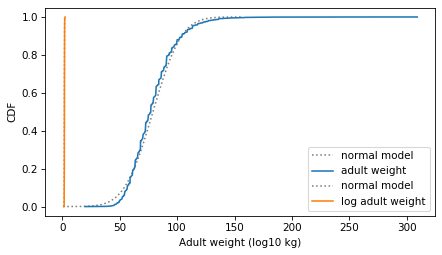

In [31]:
# Model Fitting

"""
Context: uses real adult-weight data after proportionate growth introduces the lognormal model
Plain-English: loads adult weights, compares raw weights with a normal model, then compares log weights with a normal model
Real-world: used to check whether body-weight data fits additive or proportionate growth better
Reappears: yes in transformed-data modeling and model comparison
"""

import numpy as np
from empiricaldist import Cdf
from thinkstats import read_brfss
from os.path import basename, exists  

def download(url):
    filename = basename(url)

    print(f" Downloaded {filename} from URL") 
     
    if not exists(filename):
        from urllib.request import urlretrieve  

        local, _ = urlretrieve(url, filename)  

        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/CDBRFS08.ASC.gz")  
# download BRFSS survey data file

brfss = read_brfss()  
# read BRFSS data into a DataFrame

adult_weights = brfss["wtkg2"].dropna()  
# select adult weights in kilograms and remove missing values

m, s = np.mean(adult_weights), np.std(adult_weights)  
# m is mean adult weight, s is standard deviation

print(
    "Mean and standard deviation of adult weights = ", m, s
     )

cdf_model = make_normal_model(adult_weights)  
# build normal model from raw adult weights

cdf_adult_weights = Cdf.from_seq(adult_weights, name="adult weight")  
# build empirical CDF from raw adult weights

two_cdf_plots(cdf_model, cdf_adult_weights, xlabel="Adult weight (kilograms)")  
# compare raw adult weights with normal model


log_adult_weights = np.log10(adult_weights)  
# convert adult weights to log10 scale

cdf_model = make_normal_model(log_adult_weights)  
# build normal model from log-transformed weights

cdf_log_adult_weights = Cdf.from_seq(log_adult_weights, name="log adult weight")  
# build empirical CDF from log-transformed weights

two_cdf_plots(cdf_model, cdf_log_adult_weights, xlabel="Adult weight (log10 kg)")  
# compare log adult weights with normal model


"""
Interpretation:
brfss stores the BRFSS survey data
adult_weights stores non-missing adult weights in kilograms
m stores the average adult weight
s stores how spread out adult weights are
cdf_adult_weights stores the empirical distribution of raw adult weights
log_adult_weights stores the same weights after log10 transformation
cdf_log_adult_weights stores the empirical distribution of log weights
the first plot checks whether raw adult weights look normal
the second plot checks whether log adult weights look normal
a better fit after log transformation supports the lognormal model
"""

print()